# Cats and Dogs classification
---
The dataset consists of images of cats and dogs divided into two classes. The main objective of this project is to develop and train a Convolutional Neural Network (CNN) capable of distinguishing between the two classes.

Dataset link: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

In [37]:
from pathlib import Path
import pandas as pd

from PIL import Image
from collections import Counter
import warnings

# helper classes and functions
from src.utils.helpers import DatasetImageInfo

In [2]:
# Get the absolute path to the project root directory.
# Path.cwd() returns the current working directory, which is the notebooks folder,
# and .parent moves one level up to the main project directory.
PROJECT_ROOT = Path.cwd().parent

# Define the main directory where all dataset files are stored.
DATA_DIR = PROJECT_ROOT / "01_data"

# Define the directory containing the project's Python source code.
SRC_DIR = PROJECT_ROOT / "src"

# Define the directory containing the prepared and split dataset.
PROCESSED_DIR = DATA_DIR / "processed"

# Define the directories for the training, validation, and test datasets.
TRAIN_DIR = PROCESSED_DIR / "train"
VALIDATION_DIR = PROCESSED_DIR / "validation"
TEST_DIR = PROCESSED_DIR / "test"

In [3]:
print(TRAIN_DIR.exists())
print(VALIDATION_DIR.exists())
print(TEST_DIR.exists())

True
True
True


In [4]:
list(TRAIN_DIR.iterdir())

[WindowsPath('C:/Users/sveto/OneDrive/Desktop/cats_and_dogs_classification/01_data/processed/train/cats'),
 WindowsPath('C:/Users/sveto/OneDrive/Desktop/cats_and_dogs_classification/01_data/processed/train/dogs')]

In [5]:
cats_dir = TRAIN_DIR / 'cats'

In [6]:
first_five = list(cats_dir.iterdir())[:10]

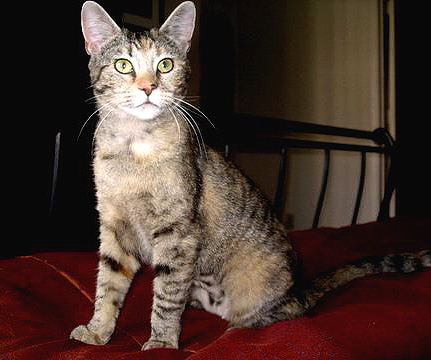

In [7]:
image = Image.open(first_five[2])
image

In [8]:
type(image)

PIL.JpegImagePlugin.JpegImageFile

In [9]:
image.size

(431, 360)

#### Checking datasets size

In [10]:
# Collect the file paths of all cat and dog images in the training dataset.
train_cats = list((TRAIN_DIR / "cats").iterdir())
train_dogs = list((TRAIN_DIR / "dogs").iterdir())

# Collect the file paths of all cat and dog images in the validation dataset.
validation_cats = list((VALIDATION_DIR / "cats").iterdir())
validation_dogs = list((VALIDATION_DIR / "dogs").iterdir())

# Collect the file paths of all cat and dog images in the test dataset.
test_cats = list((TEST_DIR / "cats").iterdir())
test_dogs = list((TEST_DIR / "dogs").iterdir())

In [11]:
print(f"Train cats: {len(train_cats)}")
print(f"Train dogs: {len(train_dogs)}")

print(f"Validation cats: {len(validation_cats)}")
print(f"Validation dogs: {len(validation_dogs)}")

print(f"Test cats: {len(test_cats)}")
print(f"Test dogs: {len(test_dogs)}")

Train cats: 8747
Train dogs: 8749
Validation cats: 1874
Validation dogs: 1874
Test cats: 1875
Test dogs: 1876


In [12]:
train_cats_instance = DatasetImageInfo(dataset=test_dogs)
train_cats_instance.dataset_image_info()

,X Mean,Y Mean,X Max,Y Max,X Min,Y Min
0,399.307036,364.826226,500,500,51,50


In [38]:
# Convert the collected image size information into a pandas DataFrame.
# This provides a tabular representation that is easier to analyze.
data_test = pd.DataFrame(train_cats_instance.dataset_image_sizes())

# Generate descriptive statistics for the image dimensions.
# This is an alternative way to explore the dataset by obtaining
# summary statistics such as the count, mean, standard deviation,
# minimum, maximum, and quartiles for the image widths and heights.
data_test.describe()

,0,1
count,1876.000000,1876.000000
mean,399.307036,364.826226
std,110.770276,97.485554
min,51.000000,50.000000
25%,320.000000,310.000000
50%,430.000000,375.000000
75%,500.000000,435.250000
max,500.000000,500.000000


In [35]:
# Collect the color mode of each image in the test dataset
image_modes = []

for image_path in test_cats + test_dogs:
    with Image.open(image_path) as image:
        image_modes.append(image.mode)

mode_count = Counter(image_modes)
print(mode_count)

Counter({'RGB': 3742, 'P': 7, 'L': 1, 'CMYK': 1})


In [33]:
for image_path in train_cats + train_dogs:
    with Image.open(image_path) as image:
        image = image.convert("RGB")

In [34]:
# Check all training images for loading errors and warning messages
for image_path in train_cats + train_dogs:
    try:
        with warnings.catch_warnings():
            # Convert warnings into exceptions so they can be caught below
            warnings.simplefilter("error")

            with Image.open(image_path) as image:
                # Force Pillow to read the complete image data
                image.load()

    except Warning as warning:
        print(f"Warning: {warning} ({image_path})")

    except OSError as error:
        print(f"Error: {error} ({image_path})")